In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import uncertainties as un
import uncertainties.unumpy as unp

from matplotlib.gridspec import GridSpec

nom = unp.nominal_values
err = unp.std_devs

In [3]:
D_calcite = {
    'Mg': un.ufloat(0.014, 0.02),  # DMg from Mucci & Morse (1983) via Hasiuk 2010 (10.1016/j.gca.2010.07.030)
    'Sr': un.ufloat(7e-2, 2e-2),  # DSr from Morse & Bender (1990)
    'Na': un.ufloat(1e-4, 0.1e-4),  # DNa from Kawabata et al (2021; 10.1016/j.chemgeo.2020.119904)
    'B': un.ufloat(1e-3, 0.2e-3),  # DB (BT/DIC) from Uchikawa et al (2015)
}

In [4]:
dat = pd.read_pickle('data/vaterite_processed.pkl')

D_vaterite = {}
for el in D_calcite:
    if el in ['Mg', 'Sr']:
        ind = dat.metadata.Experiment.isin([el, 'Mg+Sr']).values
    elif el == 'Na':
        ind = np.ones(dat.shape[0], dtype=bool)
    else:
        ind = dat.metadata.Experiment.isin([el]).values
    
        
    D_vaterite[el] = np.nanmean(dat.vaterite.loc[ind, f'D_{el}'].values)
    
D_vaterite

{'Mg': 0.05289787319423289+/-0.026729946872871682,
 'Sr': 0.21349607579281327+/-0.08651520059355668,
 'Na': 0.004237450370497079+/-0.0007503876638290044,
 'B': 0.025355725450078626+/-0.0011481641690824344}

In [43]:
SW = {
    'Ca': 0.0102821,
    'Sr': 0.0000907,
    'Mg': 0.0528171,
    'Na': 0.4689674,
    'B': 432e-6,
}

SW_ratios = {el: SW[el] / SW['Ca'] for el in SW}
SW_ratios.pop('Ca');
SW_ratios

{'Sr': 0.008821155211484034,
 'Mg': 5.136800848075782,
 'Na': 45.61007965298917,
 'B': 0.04201476352107059}

In [44]:
foram_ratio_ranges = {
    'Sr': np.array([0.5e-3, 2e-3]),
    'Mg': np.array([0.5e-3, 10e-3]),
    'Na': np.array([4e-3, 7e-3]),
    'B': np.array([10e-6, 100e-6]),
}

multipliers = {
    'Na': 1e3,
    'Mg': 1e3,
    'B': 1e5,
    'Sr': 1e4,
}

## Can double-fractionation explain foram geochemistry?

### Simple Double Fractionation

- Vaterite forms from seawater with composition set by vaterite $D_X$
- Vaterite dissolves and sets composition of internal liquid.
- Calcite forms from internal fluid with composition set by calcite $D_X$
- There is no Rayleigh fractionation between fluid and mineral at any stage.
- There is no exchange with seawater during the dissolution-reprecipitation process.

$X/Ca_{C} = X/Ca_{SW} D_X^V D_X^C$


In [45]:
calc_foram = {el: SW_ratios[el] * D_calcite[el] * D_vaterite[el] for el in SW_ratios}

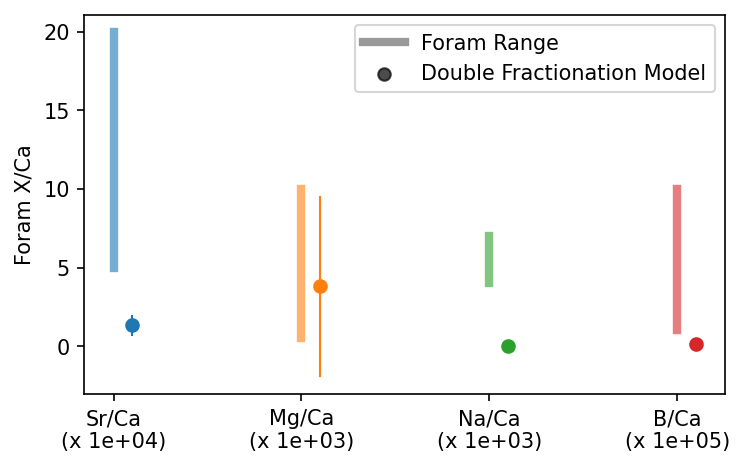

In [56]:
fig, ax = plt.subplots(constrained_layout=True)

els = list(SW_ratios.keys())

space = 0.1

for i, el in enumerate(els):
    m = np.array(multipliers[el])
    line = ax.plot([i,i], foram_ratio_ranges[el] * m, lw=4, alpha=0.6)
    
    c = line[0].get_color()
    
    ax.scatter(i + space, nom(calc_foram[el]) * m, color=c)
    ax.errorbar(i + space, nom(calc_foram[el]) * m, err(calc_foram[el]) * m, color=c, lw=0, elinewidth=1)
    
ax.set_xticks(np.arange(len(SW_ratios)))
ax.set_xticklabels([f'{el}/Ca\n(x {multipliers[el]:.0e})' for el in els])

ax.set_ylabel('Foram X/Ca')

ax.plot([],[],color='k', lw=4, alpha=0.4, label='Foram Range')
ax.scatter([],[], color='k', alpha=0.7, label='Double Fractionation Model')
ax.legend()

# ax.set_yscale('log')

### Double Fractionation with Seawater Exchange

- Vaterite forms from seawater with composition set by vaterite $D_X$
- Vaterite dissolves and sets composition of internal liquid which starts as seawater. The composition of this second fluid is a mixture between seawater ($e=1$) and vaterite ($e=0$). 
- Calcite forms from internal fluid with composition set by calcite $D_X$
- There is no Rayleigh fractionation between fluid and mineral at any stage.

![](figs/Double_Frac_Exchange.png)


$$
\begin{align}
X/Ca_{V} &= X/Ca_{SW} D_X^V \\
X/Ca_{C} &= X/Ca_{CF} D_X^C \\
X/Ca_{CF} &= X/Ca_{SW} f_E + X/Ca_{V} (1 - f_E) \\
\end{align}
$$

therefore

$$
X/Ca_{C} = [ X/Ca_{SW} f_E + (X/Ca_{SW} D_X^V) (1 - f_E) ] D_X^C
$$


In [47]:
def doublefrac_exchange(SW, DC, DV, e):
    return (SW * e + (SW * DV) * (1 - e)) * DC

In [51]:
e = np.linspace(0, 1, 100)
calc_foram_exchange = {el: doublefrac_exchange(SW=SW_ratios[el], DC=D_calcite[el], DV=D_vaterite[el], e=e) for el in SW_ratios}

Text(0.5, 0, 'Seawater Exchange Fraction ($f_E$)')

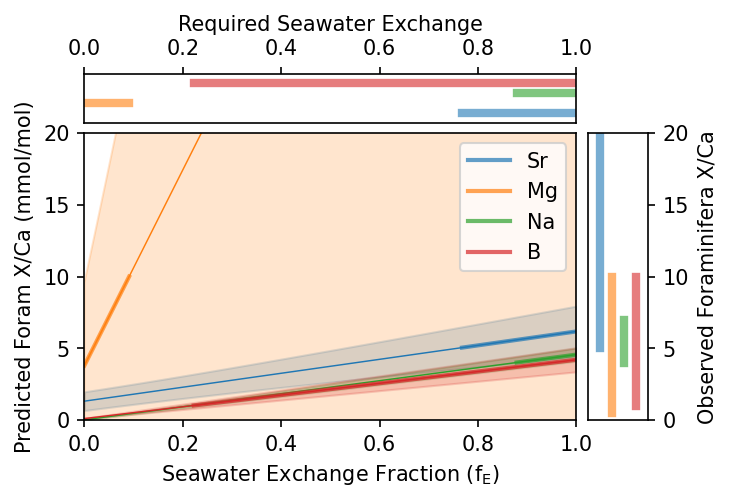

In [101]:
# fig, ax = plt.subplots(constrained_layout=True)

fig = plt.figure()

g = GridSpec(6, 8, fig)

ax = fig.add_subplot(g[1:, :-1])
rax = fig.add_subplot(g[0, :-1], sharex=ax)
rax.xaxis.tick_top()
rax.xaxis.set_label_position('top')

fax = fig.add_subplot(g[1:, -1], sharey=ax)
fax.yaxis.tick_right()
fax.yaxis.set_label_position('right')


els = list(SW_ratios.keys())


space = 0.1
y2 = 0

for i, el in enumerate(els):
    m = np.array(multipliers[el])
        
    line = ax.plot(e, nom(calc_foram_exchange[el]) * m, lw=0.7)
    c = line[0].get_color()
    
    fax.plot([i, i], foram_ratio_ranges[el] * m, lw=4, alpha=0.6, color=c)
    # line = rax.axhspan(foram_ratio_ranges[el][0] * m, foram_ratio_ranges[el][1] * m, alpha=0.4)
    # rax.axhspan(foram_ratio_ranges[el][0] * m, foram_ratio_ranges[el][1] * m, alpha=0.4, color=c, lw=0)
    
    ax.fill_between(e, nom(calc_foram_exchange[el]) * m - err(calc_foram_exchange[el]) * m, nom(calc_foram_exchange[el]) * m + err(calc_foram_exchange[el]) * m, color=c, alpha=0.2, zorder=-2)
    
    ind = (calc_foram_exchange[el] > foram_ratio_ranges[el][0]) & (calc_foram_exchange[el] < foram_ratio_ranges[el][1])
    ax.plot(e[ind], nom(calc_foram_exchange[el][ind]) * m, lw=2, color=c, label=el, alpha=0.7)
    
    rax.plot(e[ind], [i] * sum(ind), lw=4, alpha=0.6, color=c)
    
    
ax.set_ylim(0,20)
ax.set_xlim(0,1)

rax.set_ylim(-1, len(els))
rax.set_yticks([])
rax.set_xlabel('Required Seawater Exchange')

fax.set_xlim(-1, len(els))
fax.set_xticks([])
fax.set_ylabel('Observed Foraminifera X/Ca')

ax.set_ylabel('Predicted Foram X/Ca (mmol/mol)')

# ax.plot([],[],color='k', lw=4, alpha=0.4, label='Foram Range')
ax.legend(loc='upper right')
ax.set_xlabel('Seawater Exchange Fraction ($f_E$)')



### Double Fractionation with Seawater Exchange and Rayleigh Fractionation

- Vaterite forms from seawater with composition set by vaterite $D_X$ and can undergo Rayleigh fractionation ($f_1$)
- Vaterite dissolves and sets composition of internal liquid which starts as seawater. The composition of this second fluid is a mixture between seawater ($e=1$) and vaterite ($e=0$). 
- Calcite forms from internal fluid with composition set by calcite $D_X$ and can undergo Rayleigh fractionation ($f_2$)

![](figs/Double_Frac_Full.png)

$$
\begin{align}
X/Ca_V &= X/Ca_{SW} \frac{1 - f_1^{D_X^V}}{1 - f_1} \\
X/Ca_C &= X/Ca_{CF} \frac{1 - f_2^{D_X^C}}{1 - f_2} \\
X/Ca_{CF} &= X/Ca_{SW} e + X/Ca_{V} (1 - e) \\
\end{align}
$$
therefore:
$$
X/Ca_C = \left[ X/Ca_{SW} e + \left( X/Ca_{SW} \frac{1 - f_1^{D_X^V}}{1 - f_1} \right) (1 - e) \right] \frac{1 - f_2^{D_X^C}}{1 - f_2}
$$

In [103]:
def doublefrac_rayleigh(SW, DC, DV, e, f1=1, f2=1):
    DV_R = (1 - f1**DV) / (1 - f1)
    DC_R = (1 - f2**DC) / (1 - f2)
    return (SW * e + (SW * DV_R) * (1 - e)) * DC_R

In [104]:
n = 50
linvar = np.linspace(0, 1, n)
logvar = np.logspace(-4, -0.000001, n)
ge, gf1, gf2 = np.meshgrid(linvar, logvar, logvar)

calc_foram_rayleigh = {el: doublefrac_rayleigh(SW=SW_ratios[el], DC=D_calcite[el], DV=D_vaterite[el], e=ge, f1=gf1, f2=gf2) for el in SW_ratios}
viable = {el: (calc_foram_rayleigh[el] > foram_ratio_ranges[el][0]) & (calc_foram_rayleigh[el] < foram_ratio_ranges[el][1]) for el in SW_ratios}

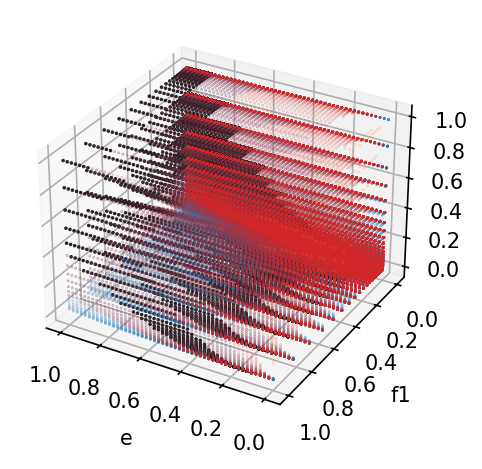

In [105]:
fig = plt.figure(constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')

for el in els:
    ind = viable[el]
    ax.scatter(ge[ind], np.log10(gf1[ind]), np.log10(gf2[ind]), s=0.1, alpha=1, label=el)

# gind = np.sum(list(viable.values()), axis=0) >= 4
# ax.scatter(ge[gind], np.log10(gf1[gind]), np.log10(gf2[gind]), s=0.5, alpha=0.9, color='k')


ax.set_xlabel('e')
ax.set_ylabel('f1')
ax.set_zlabel('f2')

# ax.set_yscale('log')
# ax.set_zscale('log')

ax.invert_xaxis()
ax.invert_yaxis()

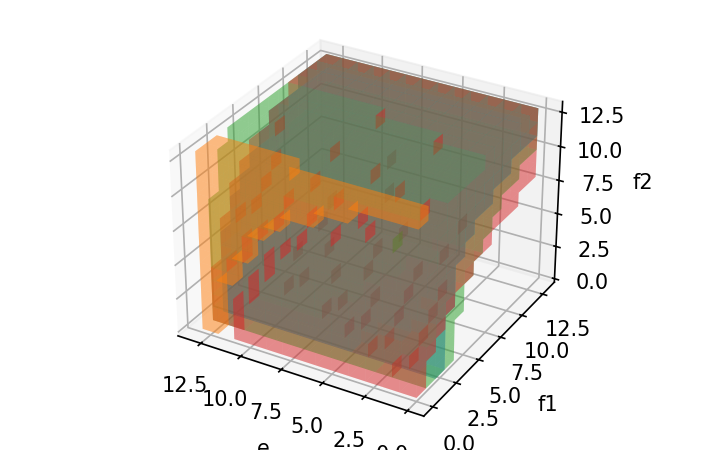

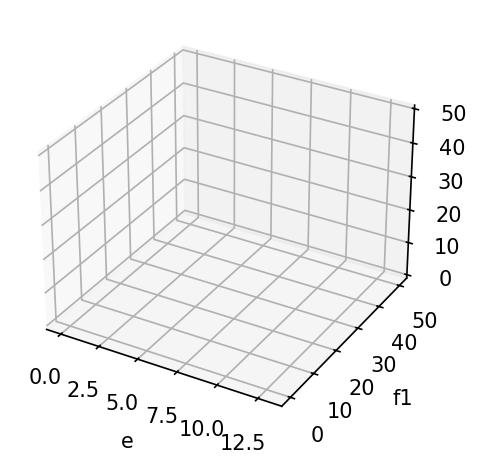

In [110]:
fig = plt.figure(constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')

# for c, el in zip(['C0','C1','C2','C3'], els):
#     ind = viable[el]
#     ax.voxels(ind[::4], alpha=0.3, facecolor=c)

gind = np.sum(list(viable.values()), axis=0) == 4
ax.voxels(gind[::4], alpha=0.3, facecolor='k');

# gind = np.sum(list(viable.values()), axis=0) >= 4
# ax.voxels(gind, alpha=0.3, facecolor='k');

ax.set_xlabel('e')
ax.set_ylabel('f1')
ax.set_zlabel('f2')

ax.invert_xaxis()
# ax.invert_yaxis()